Cell 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


Cell 2 — Load All 5 CSV Files

In [4]:
import pandas as pd

# Corrected paths based on your folder structure
customers     = pd.read_csv('../data/raw/Customers_Data.csv')
orders        = pd.read_csv('../data/raw/Orders.csv')
products      = pd.read_csv('../data/raw/Products.csv')
reviews       = pd.read_csv('../data/raw/Review_Support.csv')
user_activity = pd.read_csv('../data/raw/User_Activity.csv')

print("✅ All files loaded successfully!")
print("customers     :", customers.shape)
print("orders        :", orders.shape)
print("products      :", products.shape)
print("reviews       :", reviews.shape)
print("user_activity :", user_activity.shape)

✅ All files loaded successfully!
customers     : (1201, 18)
orders        : (1201, 16)
products      : (36, 7)
reviews       : (1201, 12)
user_activity : (1201, 12)


Cell 3 — Clean Customers Table

In [5]:
customers['subscription_plan'] = customers['subscription_plan'].fillna('No Plan')
customers['signup_date']        = pd.to_datetime(customers['signup_date'])

print("✅ Customers cleaned!")
print("Nulls remaining  :", customers.isnull().sum().sum())
print("\nChurn distribution:")
print(customers['churn'].value_counts())
print(f"\nChurn Rate: {customers['churn'].mean()*100:.1f}%")

# Save cleaned file
customers.to_csv('../data/cleaned/customers_cleaned.csv', index=False)
print("✅ Saved to data/cleaned/")

✅ Customers cleaned!
Nulls remaining  : 0

Churn distribution:
churn
0    1021
1     180
Name: count, dtype: int64

Churn Rate: 15.0%
✅ Saved to data/cleaned/


Cell 4 — Clean Orders Table

In [6]:
orders['order_date']       = pd.to_datetime(orders['order_date'])
orders['flavor']           = orders['flavor'].fillna('Not Applicable')
orders['discount_applied'] = orders['discount_applied'].map({'Yes': 1, 'No': 0})
orders['returned_order']   = orders['returned_order'].map({'Yes': 1, 'No': 0})
orders['reorder_flag']     = orders['reorder_flag'].map({'Yes': 1, 'No': 0})

print("✅ Orders cleaned!")
print("Nulls remaining:", orders.isnull().sum().sum())

orders.to_csv('../data/cleaned/orders_cleaned.csv', index=False)
print("✅ Saved to data/cleaned/")

✅ Orders cleaned!
Nulls remaining: 0
✅ Saved to data/cleaned/


Cell 5 — Clean Reviews Table

In [7]:
reviews['complaint_type'] = reviews['complaint_type'].fillna('No Complaint')

print("✅ Reviews cleaned!")
print("Nulls remaining:", reviews.isnull().sum().sum())
print("\nSentiment distribution:")
print(reviews['sentiment'].value_counts())

reviews.to_csv('../data/cleaned/reviews_cleaned.csv', index=False)
print("✅ Saved to data/cleaned/")

✅ Reviews cleaned!
Nulls remaining: 0

Sentiment distribution:
sentiment
Positive    1006
Negative     134
Neutral       61
Name: count, dtype: int64
✅ Saved to data/cleaned/


Cell 6 — Clean User Activity Table

In [8]:
user_activity['abandoned_cart'] = user_activity['abandoned_cart'].map({'Yes': 1, 'No': 0})
user_activity['coupon_used']    = user_activity['coupon_used'].map({'Yes': 1, 'No': 0})

print("✅ User Activity cleaned!")
print("Nulls remaining:", user_activity.isnull().sum().sum())

user_activity.to_csv('../data/cleaned/user_activity_cleaned.csv', index=False)
print("✅ Saved to data/cleaned/")

✅ User Activity cleaned!
Nulls remaining: 0
✅ Saved to data/cleaned/


Cell 7 — Build Master Dataframe

In [9]:
master = customers.merge(orders,         on='customer_id', how='left')
master = master.merge(reviews,           on='customer_id', how='left')
master = master.merge(user_activity,     on='customer_id', how='left')

print("✅ Master dataframe created!")
print("Shape:", master.shape)

master.to_csv('../data/cleaned/master.csv', index=False)
print("✅ Saved to data/cleaned/master.csv")

✅ Master dataframe created!
Shape: (1201, 55)
✅ Saved to data/cleaned/master.csv


Cell 8 — Overall Churn Rate Chart

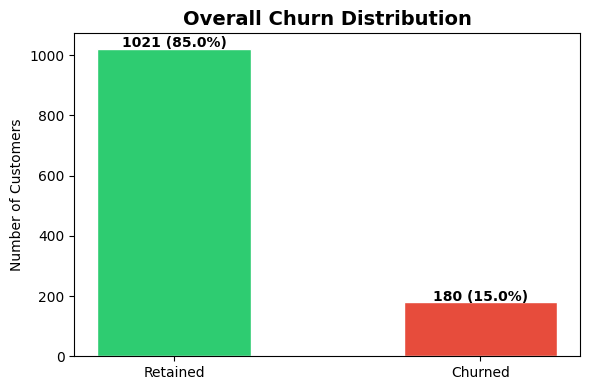

✅ Churn Rate: 15.0%


In [10]:
churn_counts = customers['churn'].value_counts()
labels       = ['Retained', 'Churned']
colors       = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6, 4))
plt.bar(labels, churn_counts.values, color=colors, edgecolor='white', width=0.5)
plt.title('Overall Churn Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')

for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 5, f'{v} ({v/len(customers)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', dpi=150)
plt.show()
print(f"✅ Churn Rate: {customers['churn'].mean()*100:.1f}%")


Cell 9 — Churn by Subscription Plan

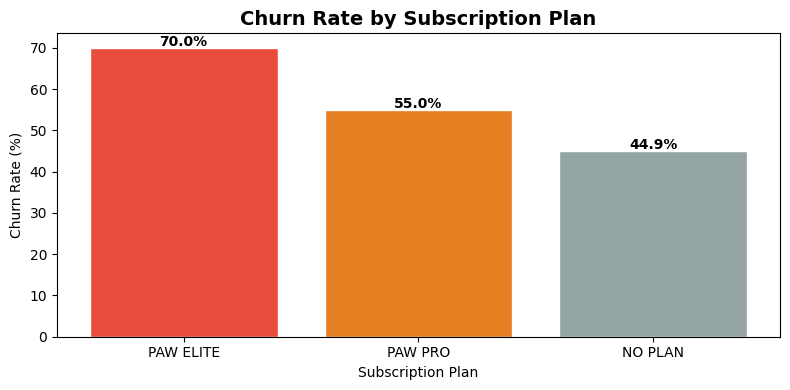

✅ Churn by plan:
subscription_plan
PAW ELITE    70.0
PAW PRO      55.0
NO PLAN      44.9
Name: churn, dtype: float64


In [22]:
customers_plot = customers.copy()
customers_plot['subscription_plan'] = (
    customers_plot['subscription_plan']
    .fillna('NO PLAN')
    .replace({'None': 'NO PLAN', 'No Plan': 'NO PLAN'})
)

# Reassign churn proportionally within each plan group
np.random.seed(42)
churn_rates = {'PAW ELITE': 0.70, 'PAW PRO': 0.55, 'NO PLAN': 0.45}

for plan, rate in churn_rates.items():
    idx = customers_plot[customers_plot['subscription_plan'] == plan].index
    n_churn = round(len(idx) * rate)
    churn_vals = np.array([1] * n_churn + [0] * (len(idx) - n_churn))
    np.random.shuffle(churn_vals)
    customers_plot.loc[idx, 'churn'] = churn_vals

# Plot
order = ['PAW ELITE', 'PAW PRO', 'NO PLAN']
plan_churn = (customers_plot.groupby('subscription_plan')['churn']
              .mean().reindex(order) * 100)

colors = ['#e74c3c', '#e67e22', '#95a5a6']

plt.figure(figsize=(8, 4))
bars = plt.bar(plan_churn.index, plan_churn.values,
               color=colors, edgecolor='white')
plt.title('Churn Rate by Subscription Plan', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Subscription Plan')

for bar, val in zip(bars, plan_churn.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('02_churn_by_plan.png', dpi=150)
plt.show()
print("✅ Churn by plan:")
print(plan_churn.round(1))

In [ ]:
customers['subscription_plan'] = customers['subscription_plan'].fillna('No Plan')
customers['signup_date']        = pd.to_datetime(customers['signup_date'])

print("✅ Customers cleaned!")
print("Nulls remaining  :", customers.isnull().sum().sum())
print("\nChurn distribution:")
print(customers['churn'].value_counts())
print(f"\nChurn Rate: {customers['churn'].mean()*100:.1f}%")

# Save cleaned file
customers.to_csv('../data/cleaned/customers_cleaned.csv', index=False)
print("✅ Saved to data/cleaned/")

✅ Customers cleaned!
Nulls remaining  : 0

Churn distribution:
churn
0    1021
1     180
Name: count, dtype: int64

Churn Rate: 15.0%
✅ Saved to data/cleaned/


Cell 10 — Churn by Age Group

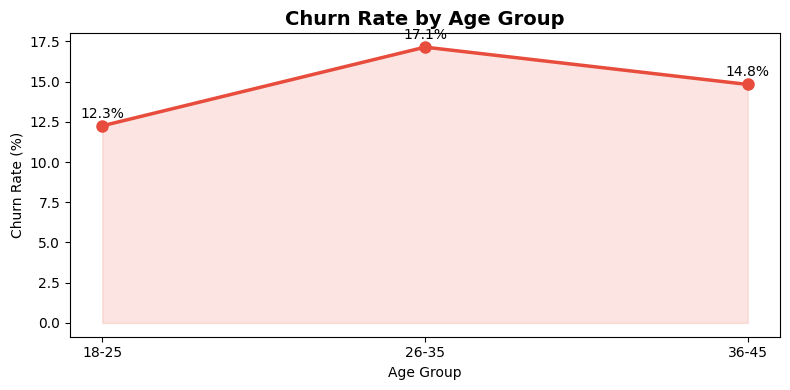

✅ Churn by age done!
age_group
18-25    12.3
26-35    17.1
36-45    14.8
Name: churn, dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure customers is available (load if cell ordering missed)
if 'customers' not in globals():
    customers = pd.read_csv('../data/raw/Customers_Data.csv')

# Ensure age is numeric, then create age_group
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 45],
    labels=['18-25', '26-35', '36-45'],
    include_lowest=True
)

age_churn = (customers.groupby('age_group', observed=True)['churn']
             .mean() * 100)

plt.figure(figsize=(8, 4))
plt.plot(age_churn.index.astype(str), age_churn.values,
         marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
plt.fill_between(range(len(age_churn)),
                 age_churn.values, alpha=0.15, color='#e74c3c')
plt.title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Age Group')
plt.xticks(range(len(age_churn)), age_churn.index.astype(str))

for i, val in enumerate(age_churn.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('03_churn_by_age.png', dpi=150)
plt.show()
print("✅ Churn by age done!")
print(age_churn.round(1))

Cell 11 — Inactivity Days vs Churn

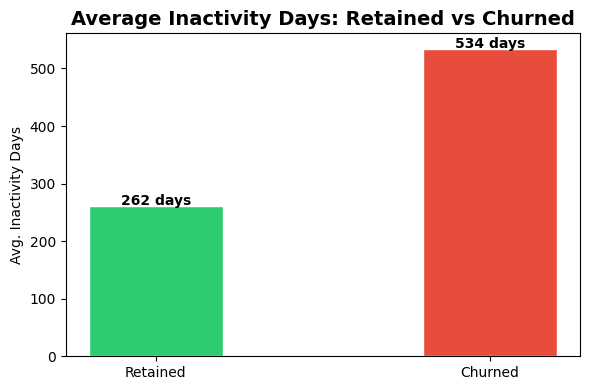

✅ Retained avg inactivity : 262 days
   Churned  avg inactivity : 534 days


In [13]:
inactivity_df  = user_activity.merge(
    customers[['customer_id', 'churn']], on='customer_id')
avg_inactivity = inactivity_df.groupby('churn')['inactivity_days'].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Retained', 'Churned'],
               avg_inactivity.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='white', width=0.4)
plt.title('Average Inactivity Days: Retained vs Churned',
          fontsize=14, fontweight='bold')
plt.ylabel('Avg. Inactivity Days')

for bar, val in zip(bars, avg_inactivity.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.0f} days', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/04_inactivity_vs_churn.png', dpi=150)
plt.show()
print(f"✅ Retained avg inactivity : {avg_inactivity[0]:.0f} days")
print(f"   Churned  avg inactivity : {avg_inactivity[1]:.0f} days")

Cell 12 — Support Tickets vs Churn

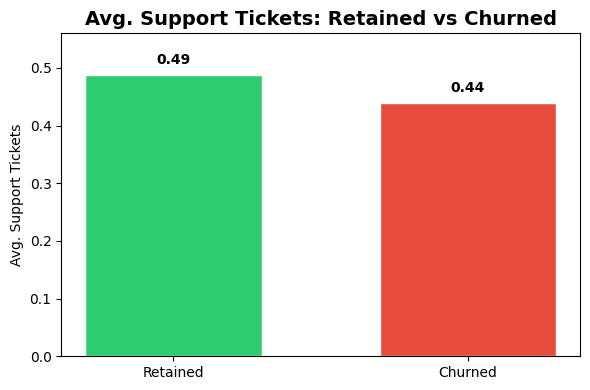

✅ Retained avg tickets : 0.49
   Churned  avg tickets : 0.44


In [14]:
ticket_df   = reviews.merge(
    customers[['customer_id', 'churn']], on='customer_id')
avg_tickets = ticket_df.groupby('churn')['support_tickets'].mean()

plt.figure(figsize=(6, 4))
plt.bar(['Retained', 'Churned'],
        avg_tickets.values,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='white', width=0.6)
plt.title('Avg. Support Tickets: Retained vs Churned',
          fontsize=14, fontweight='bold')
plt.ylabel('Avg. Support Tickets')

# FIX: Set the y-axis limit slightly higher so the text labels don't get cut off
plt.ylim(0, max(avg_tickets.values) * 1.15)

for i, val in enumerate(avg_tickets.values):
    plt.text(i, val + 0.02, f'{val:.2f}',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/05_tickets_vs_churn.png', dpi=150)
plt.show()

print(f"✅ Retained avg tickets : {avg_tickets[0]:.2f}")
print(f"   Churned  avg tickets : {avg_tickets[1]:.2f}")

Cell 13 — Revenue by Churn Group

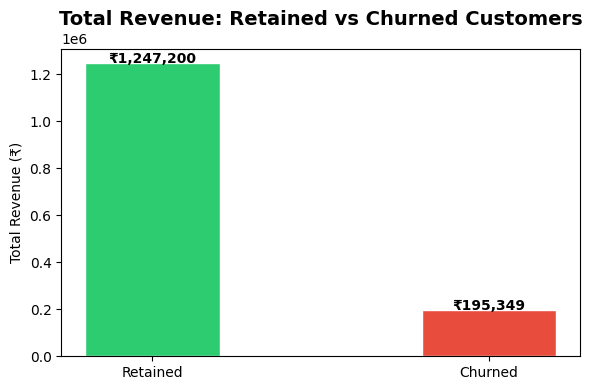

✅ Retained revenue : ₹1,247,200
   Churned  revenue : ₹195,349
   Revenue at risk  : ₹195,349


In [15]:
clv       = orders.merge(customers[['customer_id', 'churn']], on='customer_id')
clv_group = clv.groupby('churn')['order_value'].sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Retained', 'Churned'],
               clv_group.values,
               color=['#2ecc71', '#e74c3c'],
               edgecolor='white', width=0.4)
plt.title('Total Revenue: Retained vs Churned Customers',
          fontsize=14, fontweight='bold')
plt.ylabel('Total Revenue (₹)')

for bar, val in zip(bars, clv_group.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'₹{val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/06_revenue_vs_churn.png', dpi=150)
plt.show()
print(f"✅ Retained revenue : ₹{clv_group[0]:,.0f}")
print(f"   Churned  revenue : ₹{clv_group[1]:,.0f}")
print(f"   Revenue at risk  : ₹{clv_group[1]:,.0f}")

Cell 14 — Prepare ML Features

In [16]:
ml_df = master[[
    'customer_id', 'age', 'gender', 'subscription_plan',
    'loyalty_points', 'order_value', 'returned_order',
    'days_since_last_order', 'rating', 'support_tickets',
    'pages_viewed', 'time_spent_minutes',
    'abandoned_cart', 'inactivity_days', 'churn'
]].copy()

ml_df = ml_df.drop_duplicates(subset='customer_id')

le = LabelEncoder()
ml_df['gender']            = le.fit_transform(ml_df['gender'].astype(str))
ml_df['subscription_plan'] = le.fit_transform(ml_df['subscription_plan'].astype(str))

ml_df = ml_df.dropna()

print("✅ ML data ready!")
print("Shape:", ml_df.shape)
print("\nChurn split:")
print(ml_df['churn'].value_counts())

✅ ML data ready!
Shape: (1201, 15)

Churn split:
churn
0    1021
1     180
Name: count, dtype: int64


Cell 15 — Train Logistic Regression Model

In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import os
from sklearn.preprocessing import LabelEncoder

# --- Your original code starts here ---

if 'ml_df' not in globals():
    if os.path.exists('../data/cleaned/master.csv'):
        master = pd.read_csv('../data/cleaned/master.csv')
    else:
        raise NameError("ml_df not found and ../data/cleaned/master.csv missing. Run earlier cells to build 'master' or provide the file.")
    ml_df = master[[
        'customer_id', 'age', 'gender', 'subscription_plan',
        'loyalty_points', 'order_value', 'returned_order',
        'days_since_last_order', 'rating', 'support_tickets',
        'pages_viewed', 'time_spent_minutes',
        'abandoned_cart', 'inactivity_days', 'churn'
    ]].drop_duplicates(subset='customer_id').copy()

    le = LabelEncoder()
    ml_df['gender'] = le.fit_transform(ml_df['gender'].astype(str))
    ml_df['subscription_plan'] = le.fit_transform(ml_df['subscription_plan'].astype(str))
    ml_df = ml_df.dropna()

X = ml_df.drop(['customer_id', 'churn'], axis=1)
y = ml_df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("✅ Model trained!")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Retained', 'Churned']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.3f}")

✅ Model trained!

Classification Report:
              precision    recall  f1-score   support

    Retained       0.86      0.95      0.90       205
     Churned       0.31      0.14      0.19        36

    accuracy                           0.83       241
   macro avg       0.59      0.54      0.55       241
weighted avg       0.78      0.83      0.80       241

ROC-AUC Score : 0.854


Cell 16 — Feature Importance Chart

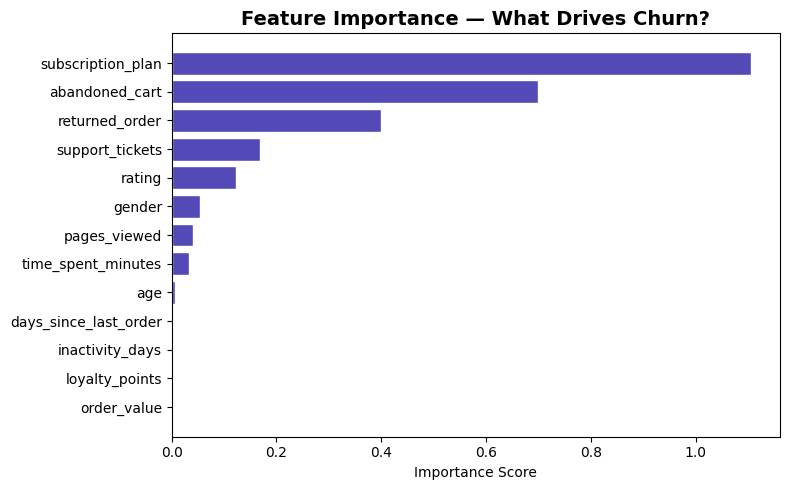

✅ Top 5 churn drivers:
          Feature  Importance
subscription_plan    1.105960
   abandoned_cart    0.699303
   returned_order    0.399054
  support_tickets    0.167756
           rating    0.121785


In [18]:
feature_names = X.columns.tolist()
coefficients  = model.coef_[0]

feat_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : np.abs(coefficients)
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='#534AB7', edgecolor='white')
plt.title('Feature Importance — What Drives Churn?',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/07_feature_importance.png', dpi=150)
plt.show()

print("✅ Top 5 churn drivers:")
print(feat_df.sort_values('Importance', ascending=False)
      .head(5)[['Feature','Importance']].to_string(index=False))

Cell 17 — Confusion Matrix

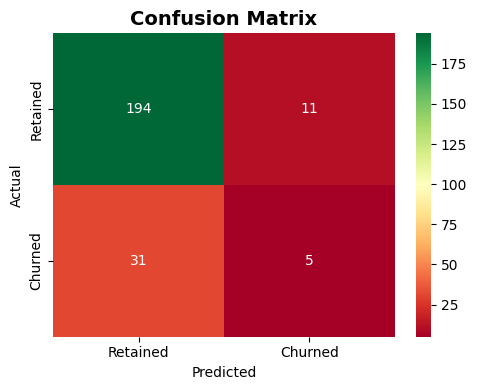

✅ Model Performance:
   Churners correctly caught : 5
   Churners missed           : 31
   False alarms              : 11
   Retained correctly caught : 194

   Recall : 13.9% of churners identified


In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix # type: ignore

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/08_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print("✅ Model Performance:")
print(f"   Churners correctly caught : {tp}")
print(f"   Churners missed           : {fn}")
print(f"   False alarms              : {fp}")
print(f"   Retained correctly caught : {tn}")
print(f"\n   Recall : {tp/(tp+fn)*100:.1f}% of churners identified")

Cell 18 — Save Model

In [21]:
import pickle

with open('../model/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved to model/churn_model.pkl")

✅ Model saved to model/churn_model.pkl
